<a href="https://colab.research.google.com/github/aishwarryaamm8/Aishwarryaa-MM---codeboosters---internship---2026/blob/main/DAY_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MACHINE LEARNING ALGORITHMS:**

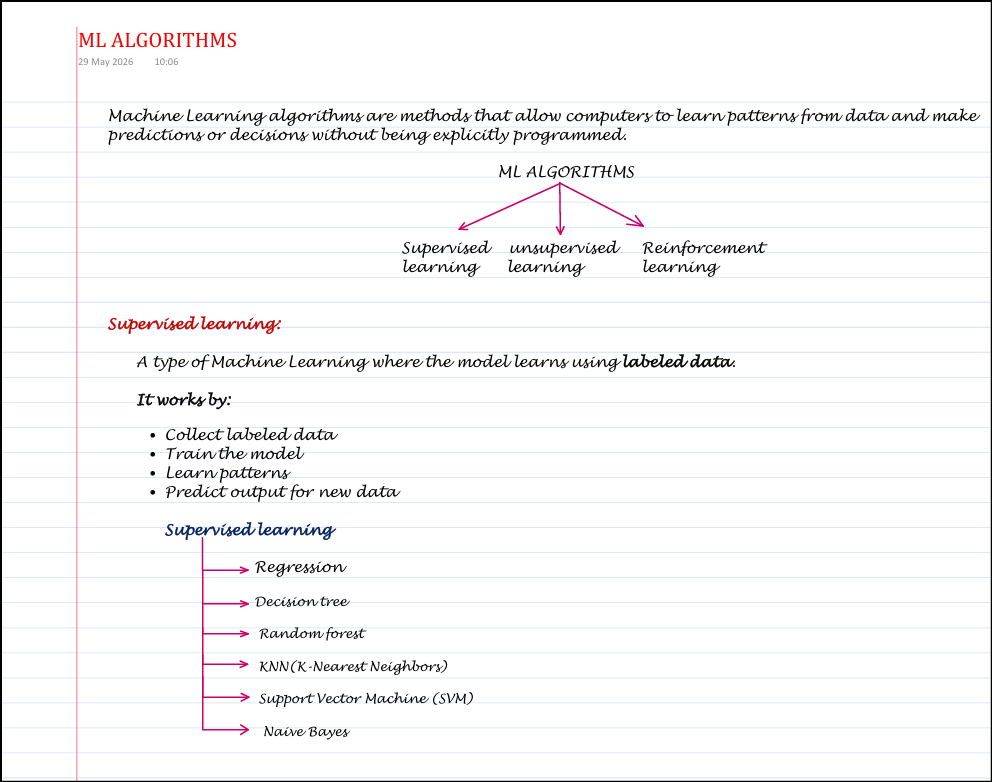



In [ ]:
import pandas as pd
df = pd.read_csv("/content/SOCR-HeightWeight.csv")

In [ ]:
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [ ]:
x = df[["Height(Inches)"]]
y = df["Weight(Pounds)"]

In [ ]:
df.isnull().any()

,0
Index,False
Height(Inches),False
Weight(Pounds),False


In [ ]:
df.isnull().sum()

,0
Index,0
Height(Inches),0
Weight(Pounds),0


# **Training model**

In [ ]:

from sklearn.model_selection import train_test_split

#This line imports the train_test_split() function from the Scikit-learn library.
#Training data → Used to train the model
#Testing data → Used to test model accuracy

#This helps check whether the model works well on new unseen data.


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
#This line splits your dataset into training data and testing data.
#x_train -	Input data used for training
#x_test  -	Input data used for testing
#y_train -  Output labels for training
#y_test	 -  Output labels for testing


In [ ]:
x_train

,Height(Inches)
7545,67.92876
4521,70.75201
18435,67.81402
14431,68.42920
418,71.04224
...,...
24941,68.40219
17093,66.83902
15128,67.85001
6675,67.61165


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
model.predict(x_train)

array([126.83420972, 135.63050492, 126.47671856, ..., 126.58885127,
       125.84620187, 129.5379508 ])

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

7.825600088454395
95.9026951550865
0.24079038363270444


In [ ]:
import joblib
joblib.dump(model, "linear.pkl")


['linear.pkl']

# **working with large sales data csv file**

In [ ]:
!pip install pyspark -quiet


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -u


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year, month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [ ]:
spark=SparkSession.builder \
.appName('Day4_BigData_Sales') \
.config('spark.sql.adaptive.enabled','true')\
.getOrCreate()

print("Spark Version:",spark.version)
print("SparkSession:ACTIVE")
print("Application:",spark.sparkContext.appName)

Spark Version: 4.0.2
SparkSession:ACTIVE
Application: Day4_BigData_Sales


In [ ]:
df_bronze = spark.read \
     .option('header', 'true')\
     .option('inferSchema', 'true')\
      .csv('large_sales_data.csv')
print('===Bronze Layer-Raw Data ===')
print(f'Rows:{df_bronze.count()}')
print(f'columns:{len(df_bronze.columns)}')
print(f'Names:{df_bronze}')
print()
df_bronze.printSchema

===Bronze Layer-Raw Data ===
Rows:5000
columns:13
Names:DataFrame[order_id: int, customer_name: string, product: string, category: string, quantity: int, unit_price: int, revenue: int, order_date: date, city: string, region: string, sales_rep: string, payment_method: string, order_status: string]



<bound method DataFrame.printSchema of DataFrame[order_id: int, customer_name: string, product: string, category: string, quantity: int, unit_price: int, revenue: int, order_date: date, city: string, region: string, sales_rep: string, payment_method: string, order_status: string]>

In [ ]:
print('First 5 rows : ')
df_bronze.show(5, truncate=False)

print('\nBasic statistics for numeric columns : ')
df_bronze.select('quantity', 'unit_price', 'revenue')

In [ ]:
df_bronze.write \
      .mode('overwrite') \
      .parquet('sales_bronze.parquet')

print('Bronze parquet saved: sales_bronze.parquet')


Bronze parquet saved: sales_bronze.parquet
